INFO:pypsa.io:Imported network basemap_V4 has buses, carriers, lines, links
/home/pypsa_eur/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


(<matplotlib.collections.PatchCollection at 0x7f7ae323b140>,
 <matplotlib.collections.LineCollection at 0x7f7adeb21a90>)

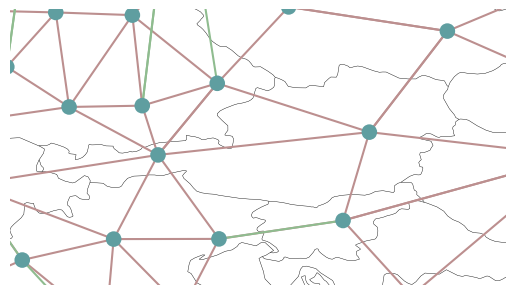

In [3]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pypsa
from datetime import datetime

# Load the network
#network_file = "/home/pypsa_eur/work/pypsa-eur-evt/results/128_wAT_entsoe_Josef/networks/base_s_128_elec_.nc"
#n = pypsa.Network("/home/pypsa_eur/work/pypsa-eur-evt/results/128_wAT_entsoe/networks/base_s_128_elec_.nc")
network_file = "/home/pypsa_eur/work/pypsa-eur-evt/basemap_V4"
n= pypsa.Network()
n.import_from_netcdf(network_file)
#u.plot()
boundaries=[9,18,45,50]
n.plot(boundaries=[9,18,45,50])
#u.plot(boundaries=[-10, 4.5, 35.5, 44])


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pypsa
from datetime import datetime

# plotting parameters
network_file = "/home/pypsa_eur/work/pypsa-eur-evt/results/128_wAT_entsoe/networks/base_s_128_elec_.nc"  # Path to network file
projection_type = "LambertConformal"  # Projection type
projection_params = {"central_longitude": 10, "central_latitude": 50}  # Parameters for the projection
title = "ENTSOE 128 Knoten mit Gewichtung auf Österreich"  # Plot title
figsize = (8.27*2, 11.69*2)  # Size of the figure (A4)
line_width = 0.5  # Line width for transmission lines
bus_size = 0.02  # Bus size
bus_color = "cadetblue"
line_color = "gray"  # Color for transmission lines (AC)
link_color = "green" # Color for HVDC transmission lines
legend_loc = 'upper right'  # Location of the legend
info_box_position = (0.95, 0.05)  # Position of the information box
font_size_title = 14  # Font size for the title
font_size_info = 8  # Font size for the info box

# Load the network
#n = pypsa.Network(network_file)
network_file = "/home/pypsa_eur/work/pypsa-eur-evt/basemap_V4"
n= pypsa.Network()
n.import_from_netcdf(network_file)

# Set up the plot with A4 dimensions and configurable projection
fig, ax = plt.subplots(figsize=figsize, subplot_kw={
    "projection": getattr(ccrs, projection_type)(**projection_params)
})

# Add features for the background map
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.OCEAN, color='lightblue')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)

# Plot the network with transmission lines and buses
n.plot(ax=ax, color_geomap=True, line_widths=line_width, link_widths=line_width, bus_sizes=bus_size, line_colors=line_color, bus_colors=bus_color)

# Iterate over buses and add their labels
for bus_id, bus in n.buses[n.buses["carrier"] == "AC"].iterrows():
    ax.text(bus.x, bus.y, bus_id, transform=ccrs.PlateCarree(),
            fontsize=6, ha='right', va='bottom', color='black',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

# Create custom legend elements
transmission_legend = mlines.Line2D([], [], color=line_color, linewidth=line_width, label="HVAC Transmission Lines")
link_legend = mlines.Line2D([], [], color=link_color, linewidth=line_width, label="HVDC Transmission Lines")
bus_legend = mlines.Line2D([], [], color=bus_color, marker='o', linestyle='None', markersize=6, label="Buses")

# Add the legend to the plot
ax.legend(handles=[transmission_legend, link_legend, bus_legend], loc=legend_loc)

# Add the title to the plot
ax.set_title(title, fontsize=font_size_title, loc='center', pad=20)

# Add the extra box with projection description, date, and additional information
date_str = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
info_text = f"Projection: {projection_type}\nDate: {date_str}\nPyPSA-Eur"

# Position the text box in the bottom-right corner
ax.text(info_box_position[0], info_box_position[1], info_text, transform=ax.transAxes, fontsize=font_size_info,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

# Save the plot as a full A4-sized PDF
plt.savefig('network_plot_a4_lambert.pdf', format='pdf', bbox_inches='tight')

# Optionally, display the plot
plt.show()


NameError: name 'pypsa' is not defined

INFO:pypsa.io:Imported network basemap_V4 has buses, carriers, lines, links
/home/pypsa_eur/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


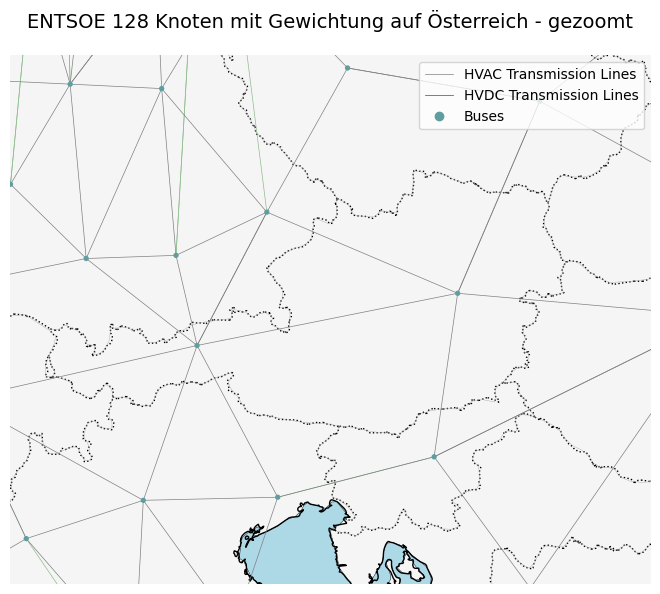

        v_nom type          x          y carrier unit  v_mag_pu_set  \
Bus                                                                   
AT0 0   380.0       15.520359  47.773819      AC                1.0   
AT0 1   380.0       11.685984  47.360277      AC                1.0   
CZ0 0   380.0       16.935731  49.607157      AC                1.0   
DE0 10  380.0       10.072208  48.230337      AC                1.0   
DE0 14  380.0       11.220347  49.896980      AC                1.0   
DE0 19  380.0       12.760185  48.659908      AC                1.0   
DE0 4   380.0       11.399496  48.254083      AC                1.0   
DE0 5   380.0        9.830404  49.945834      AC                1.0   
IT0 0   380.0        9.222265  45.452807      AC                1.0   
IT0 5   380.0       10.880916  45.832936      AC                1.0   
IT0 7   380.0       12.791807  45.836559      AC                1.0   
SI0 0   380.0       15.043369  46.170477      AC                1.0   

     

In [11]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pypsa
from datetime import datetime

# Definiere die sichtbaren Grenzen: [west, east, south, north]
#bounds = [9.3, 10.3, 43.8, 44.4] # Italy Apollo-Link
bounds=[9,18,45,50] # Austria
#bounds = [0.3, 1.4, 40.6, 41.4] # Spain Apollo-Link

# plotting parameters
network_file = "/home/pypsa_eur/work/pypsa-eur-evt/results/128_wAT_entsoe/networks/base_s_128_elec_.nc"  # Path to network file
projection_type = "LambertConformal"  # Projection type
projection_params = {"central_longitude": 10, "central_latitude": 50}  # Parameters for the projection
title = "ENTSOE 128 Knoten mit Gewichtung auf Österreich - gezoomt"  # Plot title
figsize = (8.27, 11.69)  # Size of the figure (A4)
line_width = 0.5  # Line width for transmission lines
bus_size = 0.001  # Bus size
bus_color = "cadetblue"
line_color = "gray"  # Color for transmission lines (AC)
link_color = "green" # Color for HVDC transmission lines
legend_loc = 'upper right'  # Location of the legend
info_box_position = (0.95, 0.05)  # Position of the information box
font_size_title = 14  # Font size for the title
font_size_info = 8  # Font size for the info box

# Define a narrower extent around the central point for a closer zoom
extent_lon_range = 4  # Smaller longitude range for more zoom
extent_lat_range = 3  # Smaller latitude range for more zoom
extent = [
    projection_params["central_longitude"] - extent_lon_range,
    projection_params["central_longitude"] + extent_lon_range,
    projection_params["central_latitude"] - extent_lat_range,
    projection_params["central_latitude"] + extent_lat_range
]

# Load the network
#n = pypsa.Network(network_file)
network_file = "/home/pypsa_eur/work/pypsa-eur-evt/basemap_V4"
n= pypsa.Network()
n.import_from_netcdf(network_file)

# Set up the plot with A4 dimensions and configurable projection
fig, ax = plt.subplots(figsize=figsize, subplot_kw={
    "projection": getattr(ccrs, projection_type)(**projection_params)
})

# Set the extent to crop to the center
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add features for the background map
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.OCEAN, color='lightblue')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)

# Plot the network with transmission lines and buses
n.plot(ax=ax, color_geomap=True, line_widths=line_width, link_widths=line_width, bus_sizes=bus_size, line_colors=line_color, bus_colors=bus_color, boundaries=bounds)

# Create custom legend elements
transmission_legend = mlines.Line2D([], [], color=line_color, linewidth=line_width, label="HVAC Transmission Lines")
link_legend = mlines.Line2D([], [], color=link_color, linewidth=line_width, label="HVDC Transmission Lines")
bus_legend = mlines.Line2D([], [], color=bus_color, marker='o', linestyle='None', markersize=6, label="Buses")

# Add the legend to the plot
ax.legend(handles=[transmission_legend, link_legend, bus_legend], loc=legend_loc)

# Add the title to the plot
ax.set_title(title, fontsize=font_size_title, loc='center', pad=20)

# Add the extra box with projection description, date, and additional information
date_str = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
info_text = f"Projection: {projection_type}\nDate: {date_str}\nPyPSA-Eur"

# Filtere nur die AC-Busse innerhalb der Grenzen
filtered_buses = n.buses[
    (n.buses["carrier"] == "AC") &
    (n.buses["x"] >= bounds[0]) & (n.buses["x"] <= bounds[1]) &
    (n.buses["y"] >= bounds[2]) & (n.buses["y"] <= bounds[3])
]

# Plotte den Text nur für die gefilterten Busse
#for bus_id, bus in filtered_buses.iterrows():
#    ax.text(bus.x, bus.y, bus_id, transform=ccrs.PlateCarree(),
#            fontsize=6, ha='right', va='bottom', color='black',
#           bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

# Position the text box in the bottom-right corner
#ax.text(info_box_position[0], info_box_position[1], info_text, transform=ax.transAxes, fontsize=font_size_info,
#        verticalalignment='bottom', horizontalalignment='right',
#        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

# Save the plot as a full A4-sized PDF
plt.savefig('network_plot_a4_lambert_Centered.pdf', format='pdf', bbox_inches='tight')

# Optionally, display the plot
plt.show()

print(filtered_buses)


INFO:pypsa.io:Imported network basemap_sepp has buses, carriers, lines, links, shapes, transformers
/home/pypsa_eur/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


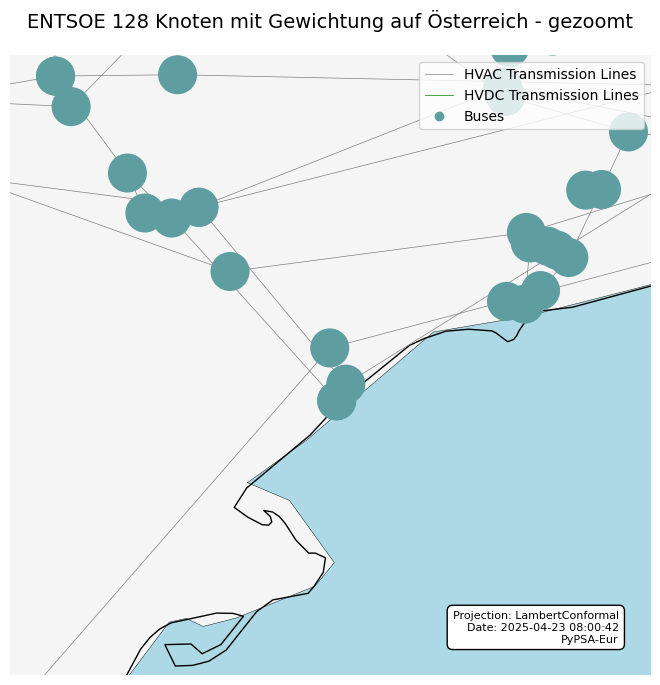

In [12]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pypsa
from datetime import datetime

# plotting parameters
network_file = "/home/pypsa_eur/work/pypsa-eur-evt/results/128_wAT_entsoe/networks/base_s_128_elec_.nc"  # Path to network file
projection_type = "LambertConformal"  # Projection type
projection_params = {"central_longitude": 10, "central_latitude": 50}  # Parameters for the projection
title = "ENTSOE 128 Knoten mit Gewichtung auf Österreich - gezoomt"  # Plot title
figsize = (8.27, 11.69)  # Size of the figure (A4)
line_width = 0.5  # Line width for transmission lines
bus_size = 0.001  # Bus size
bus_color = "cadetblue"
line_color = "gray"  # Color for transmission lines (AC)
link_color = "green" # Color for HVDC transmission lines
legend_loc = 'upper right'  # Location of the legend
info_box_position = (0.95, 0.05)  # Position of the information box
font_size_title = 14  # Font size for the title
font_size_info = 8  # Font size for the info box

# Define a narrower extent around the central point for a closer zoom
extent_lon_range = 4  # Smaller longitude range for more zoom
extent_lat_range = 3  # Smaller latitude range for more zoom
extent = [
    projection_params["central_longitude"] - extent_lon_range,
    projection_params["central_longitude"] + extent_lon_range,
    projection_params["central_latitude"] - extent_lat_range,
    projection_params["central_latitude"] + extent_lat_range
]

# Load the network
#n = pypsa.Network(network_file)
network_file = "/home/pypsa_eur/work/pypsa-eur-evt/basemap_sepp"
n= pypsa.Network()
n.import_from_netcdf(network_file)

# Set up the plot with A4 dimensions and configurable projection
fig, ax = plt.subplots(figsize=figsize, subplot_kw={
    "projection": getattr(ccrs, projection_type)(**projection_params)
})

# Set the extent to crop to the center
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add features for the background map
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.OCEAN, color='lightblue')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)

# Plot the network with transmission lines and buses
n.plot(ax=ax, color_geomap=True, line_widths=line_width, link_widths=line_width, bus_sizes=bus_size, line_colors=line_color, bus_colors=bus_color, boundaries=[0.3, 1.4, 40.6, 41.4])

# Create custom legend elements
transmission_legend = mlines.Line2D([], [], color=line_color, linewidth=line_width, label="HVAC Transmission Lines")
link_legend = mlines.Line2D([], [], color=link_color, linewidth=line_width, label="HVDC Transmission Lines")
bus_legend = mlines.Line2D([], [], color=bus_color, marker='o', linestyle='None', markersize=6, label="Buses")

# Add the legend to the plot
ax.legend(handles=[transmission_legend, link_legend, bus_legend], loc=legend_loc)

# Add the title to the plot
ax.set_title(title, fontsize=font_size_title, loc='center', pad=20)

# Add the extra box with projection description, date, and additional information
date_str = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
info_text = f"Projection: {projection_type}\nDate: {date_str}\nPyPSA-Eur"

# Position the text box in the bottom-right corner
ax.text(info_box_position[0], info_box_position[1], info_text, transform=ax.transAxes, fontsize=font_size_info,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

# Save the plot as a full A4-sized PDF
plt.savefig('network_plot_a4_lambert_Centered.pdf', format='pdf', bbox_inches='tight')

# Optionally, display the plot
plt.show()



In [18]:
import pandas as pd
from shapely.geometry import LineString
import geopandas as gpd
# Define the country code and extent of interest
country_code = "AT"
country_extent = [9,18,45,50]  # Set to the specific lat/lon bounds for Germany (adjust as needed)
network_file = "/home/pypsa_eur/work/pypsa-eur-evt/results/128_wAT_entsoe/networks/base_s_128_elec_.nc"  # Path to network file
n = pypsa.Network(network_file)
# Get lines data
lines = n.lines

# Extract node coordinates and country information from buses
buses = n.buses[['x', 'y', 'country']]

# Merge lines with bus data for both ends of each line
lines_with_buses = pd.merge(
    lines,
    buses[['country']],
    left_on='bus0', right_index=True,
    suffixes=('', '_bus0')
).merge(
    buses[['country']],
    left_on='bus1', right_index=True,
    suffixes=('', '_bus1')
)

# Get cross-border lines connected to the specified country
cross_border_lines = lines_with_buses[
    ((lines_with_buses['country'] == country_code) | (lines_with_buses['country_bus1'] == country_code)) &
    (lines_with_buses['country'] != lines_with_buses['country_bus1'])
]

# Convert lines to GeoDataFrame for plotting
line_geometries = []
for _, line in cross_border_lines.iterrows():
    line_geometry = LineString([
        (buses.loc[line['bus0'], 'x'], buses.loc[line['bus0'], 'y']),
        (buses.loc[line['bus1'], 'x'], buses.loc[line['bus1'], 'y'])
    ])
    line_geometries.append(line_geometry)

cross_border_gdf = gpd.GeoDataFrame(cross_border_lines, geometry=line_geometries)

# Set up a Cartopy map
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent(country_extent, crs=ccrs.PlateCarree())

# Add map features for context
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, color="lightgray")
ax.add_feature(cfeature.OCEAN, color="lightblue")

# Plot the cross-border lines
for line in cross_border_gdf.geometry:
    ax.plot(
        [point[0] for point in line.coords],
        [point[1] for point in line.coords],
        color="red",
        linewidth=1.5,
        transform=ccrs.PlateCarree()
    )

# Plot buses
ax.scatter(buses[buses['country'] == country_code]['x'], buses[buses['country'] == country_code]['y'],
           color='blue', s=10, transform=ccrs.PlateCarree(), label=f"{country_code} Buses")
ax.scatter(buses[buses['country'] != country_code]['x'], buses[buses['country'] != country_code]['y'],
           color='green', s=10, transform=ccrs.PlateCarree(), label="Other Country Buses")

# Customize plot
plt.title(f"Cross-Border Transmission Lines for {country_code}")
plt.legend()

# Save the plot as a full A4-sized PDF
plt.savefig(f"Cross-Border Transmission Lines for {country_code}.pdf", format='pdf', bbox_inches='tight')

plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/home/pypsa_eur/work/pypsa-eur-evt/results/128_wAT_entsoe/networks/base_s_128_elec_.nc'

INFO:pypsa.io:Imported network base_s_128_elec_.nc has buses, carriers, generators, lines, links, loads, storage_units, stores
/home/pypsa_eur/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/pypsa_eur/miniforge3/envs/pypsa-eur/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


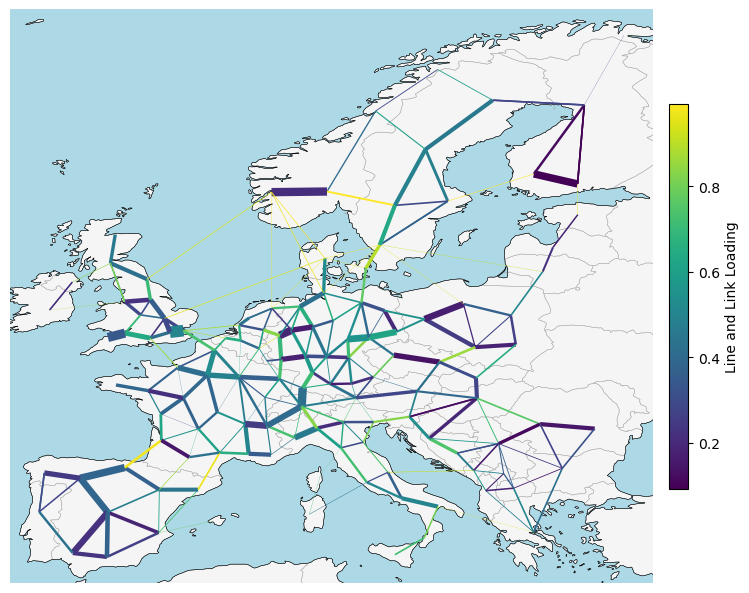

In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import pypsa
import numpy as np

network_file = "/home/pypsa_eur/work/pypsa-eur-evt/results/128_wAT_entsoe_Josef/networks/base_s_128_elec_.nc"  # Path to network file

# Load the network
n = pypsa.Network(network_file)

# Compute loading for lines
loading_lines = (n.lines_t.p0.abs().mean().reindex(n.lines.index).fillna(0.) / (n.lines.s_nom_opt * n.lines.s_max_pu)).fillna(0.)

# Filter links with carrier 'DC'
dc_links = n.links #[n.links.carrier == "DC"]
loading_links = (n.links_t.p0.abs().mean().reindex(dc_links.index).fillna(0.) / (dc_links.p_nom_opt * dc_links.p_max_pu)).fillna(0.)

# Ensure correct indexing for color mapping
loading_links = loading_links.reindex(dc_links.index).fillna(0.)

# Determine global min and max for consistent color scaling
loading_min = min(loading_lines.min(), loading_links.min())
loading_max = max(loading_lines.max(), loading_links.max())

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": ccrs.PlateCarree()})

# Plot lines and filtered links separately with the same color scheme
n.plot(ax=ax,
       bus_colors='gray',
       branch_components=["Line"],
       line_widths=n.lines.s_nom_opt / 3e3,
       line_colors=loading_lines,
       line_cmap=plt.cm.viridis,
       color_geomap=True,
       bus_sizes=0)

n.plot(ax=ax,
        branch_components=["Link"],
        link_widths=dc_links.p_nom_opt.reindex(dc_links.index).fillna(0.) / 3e3,
        link_colors=loading_links,  # Correctly assign the loading_links to line_colors
        link_cmap=plt.cm.viridis,
        color_geomap=True,
        bus_sizes=0)

ax.axis('off')

# Add a single colorbar for both lines and links
norm = plt.Normalize(vmin=loading_min, vmax=loading_max)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', shrink=0.5, pad=0.02)
cbar.set_label("Line and Link Loading")

plt.show()





In [ ]:
#network_file = "/home/pypsa_eur/work/pypsa-eur-evt/results/128_wAT_entsoe/networks/base_s_128_elec_.nc"  # Path to network file
network_file = "/home/pypsa_eur/work/pypsa-eur-evt/basemap_V1"
# Load the network
n= pypsa.Network()
n.import_from_netcdf(network_file)
#n.buses

#n = pypsa.Network(network_file)
#.p0.abs().mean()
#n.links[n.links.carrier == "DC"]
#loading_links = (n.links_t.p0.abs().mean().reindex(dc_links.index).fillna(0.) / (dc_links.p_nom_opt * dc_links.p_max_pu)).fillna(0.)
#n.links
n.links

#loading_links
#dc_links.p_nom_opt.reindex(dc_links.index).fillna(0.) / 3e3
#n.buses[(n.buses["country"] == "IT") & (n.buses["carrier"] == "AC")]
#n.buses[(n.buses["country"] == "ES") & (n.buses["carrier"] == "AC")]
#n.base_network
#[n.buses_t.marginal_price.loc[:,(n.buses["country"] == "IT") & (n.buses["carrier"] == "AC")].mean(), n.buses_t.marginal_price.loc[:,(n.buses["country"] == "ES") & (n.buses["carrier"] == "AC")].mean()]

INFO:pypsa.io:Imported network basemap_V1 has buses, carriers, lines, links, shapes, transformers


,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,ramp_limit_start_up,ramp_limit_shut_down,p_nom_opt,under_construction,voltage,tags,dc,geometry,underground,underwater_fraction
Link,,,,,,,,,,,,,,,,,,,,,
relation/10377412-320-DC,way/753113423,way/636630368,,DC,1.0,True,0,inf,1000.0,0.0,...,1.0,1.0,0.0,False,320,relation/10377412,1.0,LINESTRING (-1.194439480272105 50.818035638860...,True,0.888446
relation/13295785-515-DC,relation/12832053,way/642490160,,DC,1.0,True,0,inf,1400.0,0.0,...,1.0,1.0,0.0,False,515,relation/13295785,1.0,LINESTRING (-1.5404269162550226 55.14647596191...,True,0.983350
relation/14126301-450-DC,way/109189896,way/920127890,,DC,1.0,True,0,inf,1000.0,0.0,...,1.0,1.0,0.0,False,450,relation/14126301,1.0,LINESTRING (0.7161575436002887 51.440498299145...,True,0.977109
relation/15772117-320-DC,way/775577829,way/775577827,,DC,1.0,True,0,inf,1000.0,0.0,...,1.0,1.0,0.0,False,320,relation/15772117,1.0,LINESTRING (1.1448358124246543 51.098446880403...,True,0.714775
relation/15775538-600-DC,way/297840585,way/375626500,,DC,1.0,True,0,inf,2250.0,0.0,...,1.0,1.0,0.0,False,600,relation/15775538,1.0,LINESTRING (-4.894821189854914 55.718036768358...,True,0.892448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
conv-way/90098783,way/90098783,way/90098783-330,,,1.0,True,0,inf,700.0,0.0,...,1.0,1.0,0.0,False,300,,NaN,LINESTRING (21.257621860612392 55.681947482666...,False,0.000000
conv-way/920127890,way/920127890,way/920127890-380,,,1.0,True,0,inf,1000.0,0.0,...,1.0,1.0,0.0,False,450,,NaN,LINESTRING (4.021609637881493 51.9569589569793...,False,0.000000
conv-way/940919943,way/940919943,way/32063539-380,,,1.0,True,0,inf,600.0,0.0,...,1.0,1.0,0.0,False,400,,NaN,LINESTRING (12.216358213321973 54.100581825325...,False,0.000000
